NEPSE Stock Analysis (2010 - 2018)
Tools: Python , Pandas , NumPy , Matplotlib  
Dataset:16,029 trading records across 11 Nepali companies  
Goal: Explore stock performance, volatility, and trends in the Nepal Stock Exchange

In [118]:
pip install pandas 



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd   

In [2]:
df = pd.read_csv("stockdata.csv")

In [ ]:
df.head(10)      #Q1 Load stockdata.csv into a Pandas DataFrame. Display the first 10 rows.

,id,symbol,date,openprice,maxprice,minprice,closingprice
0,1,CHCL,4/15/2010,890,900,890,890
1,2,CHCL,4/15/2010,890,900,890,890
2,3,NABIL,4/15/2010,2000,2040,2000,2000
3,4,NTC,4/15/2010,706,455,422,455
4,5,NTC,4/15/2010,455,455,422,455
5,6,NTC,4/15/2010,455,455,422,455
6,7,SBI,4/15/2010,682,700,682,682
7,8,SBI,4/15/2010,682,700,682,682
8,9,SCB,4/15/2010,2831,2850,2825,2831
9,10,SCB,4/15/2010,2831,2850,2825,2831


In [ ]:
df.shape   #Q2. How many rows and columns does the dataset have? 
#16029 Rows and 7 Columns

(16029, 7)

In [ ]:
df["symbol"].unique()    #Q3.What are all the unique company symbols in the dataset? 
#11 unique companies

<StringArray>
[  'CHCL',  'NABIL',    'NTC',    'SBI',    'SCB',    'SHL',   'NLIC',
    'OHL',   'PLIC',   'ADBL', '\tNLIC']
Length: 11, dtype: str

In [ ]:
df["date"].min()   #Q4.  What is the date range of the data — earliest and latest trading date?

'1/1/2012'

In [31]:
df["date"].max()     #Q4

'9/9/2015'

In [ ]:
df.isnull().sum()    #Q5 Check for missing values in each column. Are there any? 
#No missing values.

id              0
symbol          0
date            0
openprice       0
maxprice        0
minprice        0
closingprice    0
dtype: int64

In [5]:
df["symbol"].str.contains('\t')
df[df["symbol"].str.contains('\t',na = False)]

,id,symbol,date,openprice,maxprice,minprice,closingprice
14517,14518,\tNLIC,2/1/2018,1800,1807,1790,1795
14527,14528,\tNLIC,2/4/2018,1795,1809,1780,1786
14537,14538,\tNLIC,2/5/2018,1510,1496,1495,1495
14547,14548,\tNLIC,2/6/2018,1760,1790,1760,1770
14557,14558,\tNLIC,2/7/2018,1770,1800,1755,1760
...,...,...,...,...,...,...,...
15484,15485,\tNLIC,7/1/2018,998,1002,992,992
15494,15495,\tNLIC,7/2/2018,992,999,983,991
15504,15505,\tNLIC,7/3/2018,991,1005,987,994
15514,15515,\tNLIC,7/4/2018,994,1012,994,1008


In [6]:
df["symbol"] = df["symbol"].replace("\tNLIC","NLIC")

In [ ]:
print('after:',df["symbol"].unique())  
#Q6.  The symbol column has a dirty entry '\tNLIC' (hidden tab character).Fix it so all entries show as 'NLIC'.

after: <StringArray>
['CHCL', 'NABIL', 'NTC', 'SBI', 'SCB', 'SHL', 'NLIC', 'OHL', 'PLIC', 'ADBL']
Length: 10, dtype: str


In [ ]:
df["date"] = pd.to_datetime(df["date"])  #Q7.  Convert the date column from string to proper datetime format.
df.describe()

,id,date,openprice,maxprice,minprice,closingprice
count,16029.000000,16029,16029.000000,16029.000000,16029.00000,16029.000000
mean,8015.000000,2014-08-16 01:43:45.715890,1137.651132,1151.568844,1123.52012,1137.760309
min,1.000000,2010-04-15 00:00:00,0.000000,0.000000,0.00000,0.000000
25%,4008.000000,2012-10-04 00:00:00,490.000000,497.000000,481.00000,490.000000
50%,8015.000000,2014-08-20 00:00:00,813.000000,821.000000,802.00000,814.000000
75%,12022.000000,2016-06-29 00:00:00,1650.000000,1675.000000,1625.00000,1650.000000
max,16029.000000,2018-09-26 00:00:00,5670.000000,5760.000000,5570.00000,5670.000000
std,4627.318068,NaN,902.801143,913.571582,890.78213,902.802729


In [ ]:
df.drop(columns = "id")   #Q8.  Drop the id column.

,symbol,date,openprice,maxprice,minprice,closingprice
0,CHCL,2010-04-15,890,900,890,890
1,CHCL,2010-04-15,890,900,890,890
2,NABIL,2010-04-15,2000,2040,2000,2000
3,NTC,2010-04-15,706,455,422,455
4,NTC,2010-04-15,455,455,422,455
...,...,...,...,...,...,...
16024,PLIC,2018-09-24,532,532,520,520
16025,SHL,2018-09-24,249,253,249,253
16026,SCB,2018-09-24,710,714,709,709
16027,SCB,2018-09-26,710,715,708,708


In [ ]:
(df["closingprice"]== 0).sum() 
#Q9.  Remove all rows where closingprice is 0 (bad/corrupted data).How many rows were removed?
#total 11 rows removed


np.int64(11)

In [11]:
df = df[df["closingprice"]!=0]

In [12]:
(df["closingprice"]== 0).sum()

np.int64(0)

In [ ]:
df.shape  #Q10. After cleaning, how many records does each company have? Which company has the most trading days recorded?

(16018, 7)

In [14]:
df["symbol"].value_counts() #SCB has highest trading days recorded.

symbol
SCB      1809
NABIL    1796
NTC      1779
SBI      1761
CHCL     1753
PLIC     1708
NLIC     1509
ADBL     1367
OHL      1292
SHL      1244
Name: count, dtype: int64

In [15]:
import pandas as pd

In [3]:
df = pd.read_csv("stockdata.csv")

In [ ]:
df["daily_change"] = df["closingprice"] - df["openprice"] #Q11. Add a new column daily_change = closingprice - openprice. What does a positive value mean? What does a negative value mean?

In [17]:
df.head(20) #positive value means the stock price increased and closed with a higher value & viceversa.

,id,symbol,date,openprice,maxprice,minprice,closingprice,daily_change
0,1,CHCL,2010-04-15,890,900,890,890,0
1,2,CHCL,2010-04-15,890,900,890,890,0
2,3,NABIL,2010-04-15,2000,2040,2000,2000,0
3,4,NTC,2010-04-15,706,455,422,455,-251
4,5,NTC,2010-04-15,455,455,422,455,0
5,6,NTC,2010-04-15,455,455,422,455,0
6,7,SBI,2010-04-15,682,700,682,682,0
7,8,SBI,2010-04-15,682,700,682,682,0
8,9,SCB,2010-04-15,2831,2850,2825,2831,0
9,10,SCB,2010-04-15,2831,2850,2825,2831,0


In [18]:
df["daily_change_pct"] = ((df["daily_change"]/ df["openprice"]) * 100).round(1)


In [ ]:
df.head(20) #Q12 Add a new column daily_change_pct = percentage change from open to close price.

,id,symbol,date,openprice,maxprice,minprice,closingprice,daily_change,daily_change_pct
0,1,CHCL,2010-04-15,890,900,890,890,0,0.0
1,2,CHCL,2010-04-15,890,900,890,890,0,0.0
2,3,NABIL,2010-04-15,2000,2040,2000,2000,0,0.0
3,4,NTC,2010-04-15,706,455,422,455,-251,-35.6
4,5,NTC,2010-04-15,455,455,422,455,0,0.0
5,6,NTC,2010-04-15,455,455,422,455,0,0.0
6,7,SBI,2010-04-15,682,700,682,682,0,0.0
7,8,SBI,2010-04-15,682,700,682,682,0,0.0
8,9,SCB,2010-04-15,2831,2850,2825,2831,0,0.0
9,10,SCB,2010-04-15,2831,2850,2825,2831,0,0.0


In [20]:
df["price_range"] = df["maxprice"] - df["minprice"]

In [ ]:
df.head(20) #Q13 Add a new column price_range = maxprice - minprice. What does a large value mean?
#large value means the specific stock price went up higher compared to others

,id,symbol,date,openprice,maxprice,minprice,closingprice,daily_change,daily_change_pct,price_range
0,1,CHCL,2010-04-15,890,900,890,890,0,0.0,10
1,2,CHCL,2010-04-15,890,900,890,890,0,0.0,10
2,3,NABIL,2010-04-15,2000,2040,2000,2000,0,0.0,40
3,4,NTC,2010-04-15,706,455,422,455,-251,-35.6,33
4,5,NTC,2010-04-15,455,455,422,455,0,0.0,33
5,6,NTC,2010-04-15,455,455,422,455,0,0.0,33
6,7,SBI,2010-04-15,682,700,682,682,0,0.0,18
7,8,SBI,2010-04-15,682,700,682,682,0,0.0,18
8,9,SCB,2010-04-15,2831,2850,2825,2831,0,0.0,25
9,10,SCB,2010-04-15,2831,2850,2825,2831,0,0.0,25


In [ ]:
#Q14. Add a new column day_result with value 'Up', 'Down', or 'Flat' read based on daily_change.
def get_result(change):
    if change > 0:
        return "Up"
    elif change < 0:
        return "Down"
    else:
        return "Flat"

df["day_result"] = df["daily_change"].apply(get_result)

In [23]:
df.head(20)

,id,symbol,date,openprice,maxprice,minprice,closingprice,daily_change,daily_change_pct,price_range,day_result
0,1,CHCL,2010-04-15,890,900,890,890,0,0.0,10,Flat
1,2,CHCL,2010-04-15,890,900,890,890,0,0.0,10,Flat
2,3,NABIL,2010-04-15,2000,2040,2000,2000,0,0.0,40,Flat
3,4,NTC,2010-04-15,706,455,422,455,-251,-35.6,33,Down
4,5,NTC,2010-04-15,455,455,422,455,0,0.0,33,Flat
5,6,NTC,2010-04-15,455,455,422,455,0,0.0,33,Flat
6,7,SBI,2010-04-15,682,700,682,682,0,0.0,18,Flat
7,8,SBI,2010-04-15,682,700,682,682,0,0.0,18,Flat
8,9,SCB,2010-04-15,2831,2850,2825,2831,0,0.0,25,Flat
9,10,SCB,2010-04-15,2831,2850,2825,2831,0,0.0,25,Flat


In [ ]:
#Q15.Extract year and month from the date column and add them as separate columns.
df["date"] = pd.to_datetime(df["date"]) 

In [25]:
df["year"] = df["date"].dt.year

In [26]:
df["month"] = df["date"].dt.month

In [27]:
df.head()

,id,symbol,date,openprice,maxprice,minprice,closingprice,daily_change,daily_change_pct,price_range,day_result,year,month
0,1,CHCL,2010-04-15,890,900,890,890,0,0.0,10,Flat,2010,4
1,2,CHCL,2010-04-15,890,900,890,890,0,0.0,10,Flat,2010,4
2,3,NABIL,2010-04-15,2000,2040,2000,2000,0,0.0,40,Flat,2010,4
3,4,NTC,2010-04-15,706,455,422,455,-251,-35.6,33,Down,2010,4
4,5,NTC,2010-04-15,455,455,422,455,0,0.0,33,Flat,2010,4


In [28]:
#Q16.For each company find the average closing price across all years.Which company has the highest average?
df.groupby("symbol")["closingprice"].mean().round(2).sort_values(ascending=False) 
#NLIC has highest average price.

symbol
NLIC     2443.74
SCB      2049.60
NABIL    1675.93
CHCL     1182.88
SBI       932.66
PLIC      862.06
NTC       590.88
OHL       436.85
ADBL      424.77
SHL       359.50
Name: closingprice, dtype: float64

In [29]:
#Q17. Find the single highest closing price ever recorded.Which company and on which date did it happen?
idx = df["closingprice"].idxmax()
df.loc[idx] 

#NLIC ON 2014-04-29.

id                                 7285
symbol                             NLIC
date                2014-04-29 00:00:00
openprice                          5650
maxprice                           5725
minprice                           5550
closingprice                       5670
daily_change                         20
daily_change_pct                    0.4
price_range                         175
day_result                           Up
year                               2014
month                                 4
Name: 7284, dtype: object

In [30]:
#Q18. Find the single lowest closing price ever recorded (greater than 0).Which company and on which date?
idx = df["closingprice"].idxmin()
df.loc[idx]

#OHL on  2011-10-23.


id                                 2243
symbol                              OHL
date                2011-10-23 00:00:00
openprice                            63
maxprice                             63
minprice                             61
closingprice                         61
daily_change                         -2
daily_change_pct                   -3.2
price_range                           2
day_result                         Down
year                               2011
month                                10
Name: 2242, dtype: object

In [31]:
#Q19. Which company had the most number of 'Up' days? Which had the most 'Down' days?
up_days = df[df["day_result"]=="Up"].groupby("symbol")["day_result"].count()
print(up_days.sort_values(ascending = False))

#SCB has most number of up days.

symbol
SCB      834
SBI      802
NABIL    783
NTC      780
CHCL     777
PLIC     761
NLIC     682
ADBL     592
OHL      567
SHL      560
Name: day_result, dtype: int64


In [32]:
down_days = df[df["day_result"]== "Down"].groupby("symbol")["day_result"].count()
print(down_days.sort_values(ascending = False))

#NABIL has most number of down days.

symbol
NABIL    900
SCB      882
SBI      847
CHCL     844
PLIC     826
NTC      744
NLIC     709
ADBL     641
OHL      587
SHL      527
Name: day_result, dtype: int64


In [33]:
#Q20. What percentage of all trading days across all companies were 'Up' days?
((df["day_result"]== "Up").sum()/len(df)* 100).round(2)

np.float64(44.56)

In [34]:
#Q21. Using groupby, find the average closing price for each company for each year. Which company grew the most from 2010 to 2018?
yearly_avg = df.groupby(["symbol","year"])["closingprice"].mean().round(2).unstack()
print(yearly_avg)

year       2010     2011     2012     2013     2014     2015     2016  \
symbol                                                                  
ADBL        NaN      NaN   165.24   262.25   510.43   462.41   698.35   
CHCL     930.63   872.45   865.67  1250.42  1941.29  1508.65  1279.33   
NABIL   1838.63  1096.38  1236.63  1902.87  2137.14  2096.80  2043.99   
NLIC     683.12   647.70  1006.61  1899.79  4150.92  3620.81  3573.13   
NTC      453.21   424.21   522.43   590.79   638.84   633.41   682.52   
OHL      144.90    82.32    91.63   166.67   623.86   628.09   515.26   
PLIC     213.70   170.48   223.17   338.82   853.80  1199.60  1937.84   
SBI      703.44   521.69   568.94   842.34  1064.25  1141.97  1681.28   
SCB     2578.35  1638.15  1711.28  1856.84  2073.74  2272.23  3119.94   
SHL      226.55   214.12   255.24   308.40   530.08   438.14   367.95   

year       2017     2018  
symbol                    
ADBL     465.47   331.03  
CHCL     813.89   778.22  
NABIL   1516.36

In [35]:
price_2010 = yearly_avg[2010]

In [36]:
price_2018 = yearly_avg[2018]

In [37]:
growth = ((price_2018 - price_2010)/price_2010 * 100).round(2)
print("growth from 2010 to 2018")
print(growth.sort_values(ascending = False))

growth from 2010 to 2018
symbol
OHL      276.69
PLIC     233.66
NLIC      74.08
NTC       64.01
SHL       10.29
CHCL     -16.38
SBI      -24.51
NABIL    -47.00
SCB      -68.64
ADBL        NaN
dtype: float64


In [38]:
#Q22. Which year had the highest average closing price across all companies?

df.groupby("year")["closingprice"].mean().round(2).sort_values(ascending= False)

year
2016    1599.68
2014    1461.85
2015    1426.72
2017    1219.78
2010    1084.25
2013     987.46
2012     726.84
2011     726.83
2018     687.58
Name: closingprice, dtype: float64

In [39]:
#Q23. Which month (1-12) tends to have the highest average closing price across all companies?
df.groupby("month")["closingprice"].mean().round(2).sort_values(ascending = False)

month
10    1187.75
8     1165.00
7     1158.30
11    1154.12
9     1145.87
1     1144.76
4     1141.48
12    1132.58
3     1126.39
2     1115.77
6     1109.06
5     1093.68
Name: closingprice, dtype: float64

In [40]:
#Q24. Find the top 5 single best trading days — highest daily_change_pct — across all companies.
df.nlargest(5,"daily_change_pct")[["date","symbol","closingprice","daily_change_pct"]].reset_index(drop = True)

,date,symbol,closingprice,daily_change_pct
0,2014-06-18,ADBL,504,inf
1,2014-06-18,CHCL,2375,inf
2,2014-06-18,NABIL,2360,inf
3,2014-06-18,NLIC,3560,inf
4,2014-06-18,NTC,615,inf


In [41]:
#Q25. Find the top 5 single worst trading days — lowest daily_change_pct — across all companies.

df.nsmallest(5,"daily_change_pct")[["date","symbol","closingprice","daily_change_pct"]].reset_index(drop = True)

,date,symbol,closingprice,daily_change_pct
0,2013-04-23,NLIC,1358,-38.1
1,2010-04-15,NTC,455,-35.6
2,2014-05-06,NLIC,3656,-35.3
3,2010-09-28,NABIL,1350,-33.6
4,2015-05-26,NLIC,2390,-33.5


In [42]:
import numpy as np

In [43]:
##Q26. Using NumPy, calculate the mean closing price of the entire dataset.

print(f"Mean Closing Price: {np.mean(df['closingprice']).round(2)}")

Mean Closing Price: 1138.54


In [44]:
#Q27. Using NumPy, calculate the median closing price of the entire dataset. Is it higher or lower than the mean? What does that tell you?

print(f"Median closing price: {np.median(df["closingprice"]).round(2)}")

Median closing price: 815.0


In [45]:
#Q28. Using NumPy, calculate the standard deviation of closing price for each company. Which company is most volatile?

df.groupby("symbol")["closingprice"].apply(np.std).round(2).sort_values(ascending =False)

symbol
NLIC     1350.11
PLIC      719.38
SCB       667.18
NABIL     492.62
CHCL      421.84
SBI       403.10
OHL       236.49
ADBL      185.90
SHL       111.53
NTC       106.34
Name: closingprice, dtype: float64

In [46]:
#Q29. Using NumPy, calculate the minimum and maximum closing price of NABIL without using Pandas.

nabil_df = df[df["symbol"] == "NABIL"]
nabil_prices = nabil_df["closingprice"].to_numpy()
min_price = np.min(nabil_prices)
max_price = np.max(nabil_prices)

print(f"Minimum price CP: {min_price}")
print(f"Maximum price CP: {min_price}")

Minimum price CP: 356
Maximum price CP: 356


In [ ]:
#Q30. Filter only NTC closing prices into a NumPy array.How many values are above the overall mean?

ntc_prices = df[df["symbol"] == "NTC"]["closingprice"].to_numpy()

ntc_mean = np.mean(ntc_prices)

above_mean = np.sum(ntc_prices > ntc_mean)

print("=== NTC Closing Prices vs Overall Mean ===")
print(f"Total NTC trading days : {len(ntc_prices)}")
print(f"Overall NTC mean   : {round(ntc_mean, 2)}")
print(f"NTC prices above mean  : {above_mean}")
print(f"NTC prices below mean  : {len(ntc_prices) - above_mean}")
print(f"Percentage above mean  : {round(above_mean / len(ntc_prices) * 100, 2)}%")

=== NTC Closing Prices vs Overall Mean ===
Total NTC trading days : 1779
Overall NTC mean   : 590.88
NTC prices above mean  : 1103
NTC prices below mean  : 676
Percentage above mean  : 62.0%


In [48]:
#Q31. Using NumPy, calculate the correlation between NABIL and NTC closing prices. Do they move together?
nabil = df[df["symbol"] == "NABIL"]["closingprice"].to_numpy()
ntc = df[df["symbol"] == "NTC"]["closingprice"].to_numpy()

print(f"NABIL length: {len(nabil)}")
print(f"NTC length: {len(ntc)}")

NABIL length: 1796
NTC length: 1779


In [49]:
min_len = min(len(nabil),len(ntc))
nabil = nabil[:min_len]
ntc = ntc[:min_len]

In [50]:
corr_bet = np.corrcoef(nabil,ntc)
correlation = corr_bet[0,1].round(2)

print("NABIL Vs. NTC correlation")
print(f"correlation: {correlation}")

NABIL Vs. NTC correlation
correlation: 0.33


In [51]:
if correlation > 0:
    print("Move together")
elif correlation == 0:
    print("Move independently")
else:
    print("Move in opposite direction")


Move together


In [52]:
#Q32. Using NumPy, calculate the 25th, 50th, and 75th percentile of closing prices for SCB.

scb_prices = df[df["symbol"] == "SCB"]["closingprice"].to_numpy()
q1 = np.percentile(scb_prices, 25).round(2)
q2 = np.percentile(scb_prices,50).round(2)
q3 = np.percentile(scb_prices,75).round(2)

print("Percentile of closing price for SCB")
print(f"25th percentile (Q1): {q1}")
print(f"50th percentile (Q2): {q2}")
print(f"75th percentile (Q3): {q3}")



Percentile of closing price for SCB
25th percentile (Q1): 1743.0
50th percentile (Q2): 1941.0
75th percentile (Q3): 2361.0


In [53]:
#Q33. Using NumPy, add 10% to every closing price in the dataset (simulate a market-wide 10% growth). What is the new mean?

prices = df["closingprice"].to_numpy()
new_prices = prices * 1.1

old_mean = np.mean(prices).round(2)
new_mean = np.mean(new_prices).round(2)
print(f"old mean: {old_mean}")
print(f"new mean: {new_mean}")


old mean: 1138.54
new mean: 1252.4


In [54]:
#Q34. Using NumPy, find how many trading days had a daily_change_pct greater than 5% or less than -5% (extreme days).

change = df["daily_change_pct"].to_numpy()

above_5 = change > 5
belowneg_5 = change < -5

total_up = np.sum(above_5)
total_down = np.sum(belowneg_5)

print(f"Greater than 5% : {total_up}")
print(f"Less than -5% : {total_down}")


Greater than 5% : 573
Less than -5% : 346


In [55]:
#Q35. Using NumPy, calculate the cumulative sum of daily_change for NABIL over all trading days. Did NABIL end higher or lower overall?

nabil_changes = df[df["symbol"] == "NABIL"]["daily_change"].to_numpy()
cumulative = np.cumsum(nabil_changes)

start = cumulative[0].round(2)
end = cumulative[-1].round(2)

print(f"starting cumsum: {start}")
print(f"ending cumsum: {end}")

if end >0 :
    print("\n Nabil ended higher")
else:
    print("\n Nabil ended lower")

      

starting cumsum: 0
ending cumsum: 1656

 Nabil ended higher


In [56]:
import matplotlib.pyplot as plt

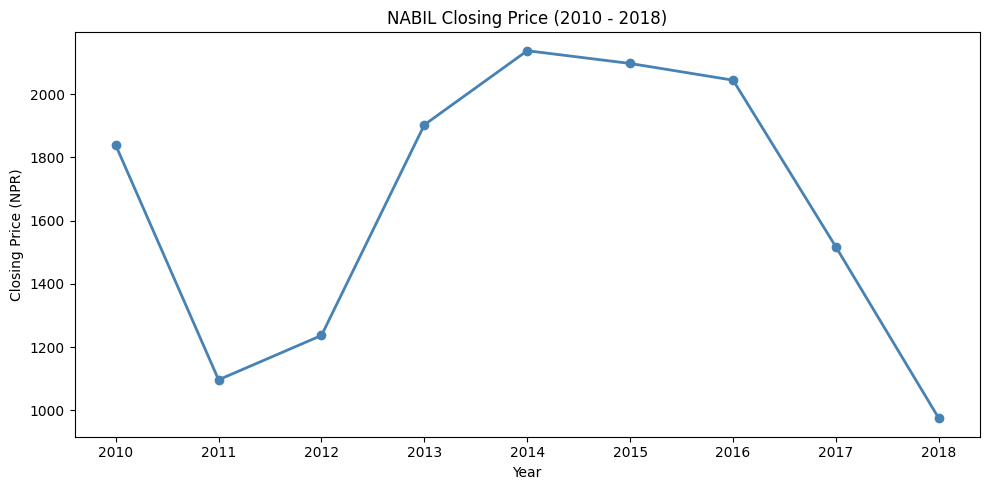

In [57]:
#Q36. Plot a line chart showing the closing price of NABIL from 2010 to 2018. Add proper title, xlabel, ylabel.

nabil = df[
    (df["symbol"] == "NABIL") &
    (df["year"] >= 2010)&
    (df["year"] <= 2018)
]
nabil_yearly = nabil.groupby("year")["closingprice"].mean()

plt.figure(figsize=(10, 5))
plt.plot(nabil_yearly.index, nabil_yearly.values, marker="o", color="steelblue", linewidth=2)

plt.title("NABIL Closing Price (2010 - 2018)")
plt.xlabel("Year")
plt.ylabel("Closing Price (NPR)")

plt.tight_layout()
plt.show()



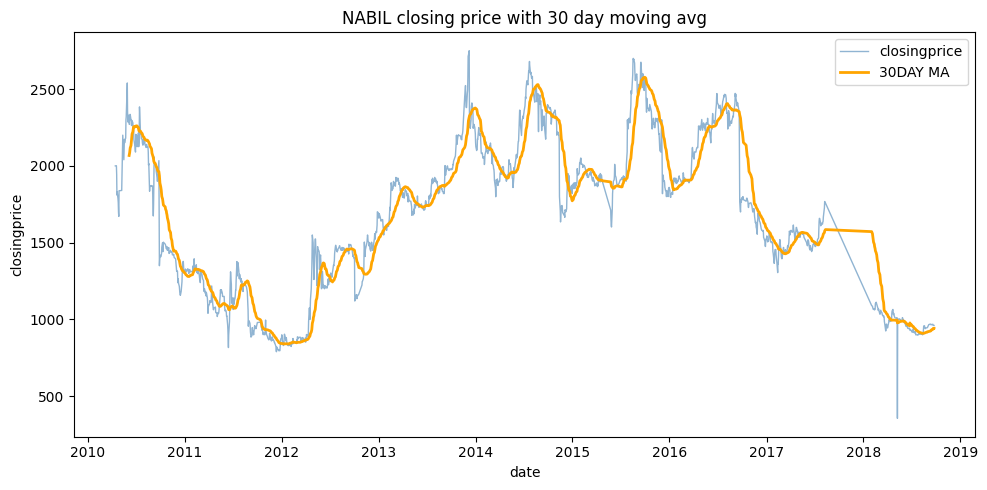

In [58]:
#Q37. On the same chart as Q36, add a 30-day moving average line in a different colour. Add a legend.

nabil = df[
    (df["symbol"] == "NABIL")&
    (df["year"]>= 2010)&
    (df["year"] <= 2018)
].copy()
nabil = nabil.sort_values("date")
nabil["MA30"] = nabil["closingprice"].rolling(window = 30).mean()

plt.figure(figsize =(10,5))
plt.plot(nabil["date"],nabil["closingprice"],
         color ="steelblue",
         linewidth = 1,
         alpha =0.6,
         label ="closingprice")
plt.plot(nabil["date"],nabil["MA30"],
          color ="orange",
          linewidth = 2,
          label = "30DAY MA")
plt.title("NABIL closing price with 30 day moving avg")
plt.xlabel("date")
plt.ylabel("closingprice")
plt.legend()

plt.tight_layout()
plt.show()

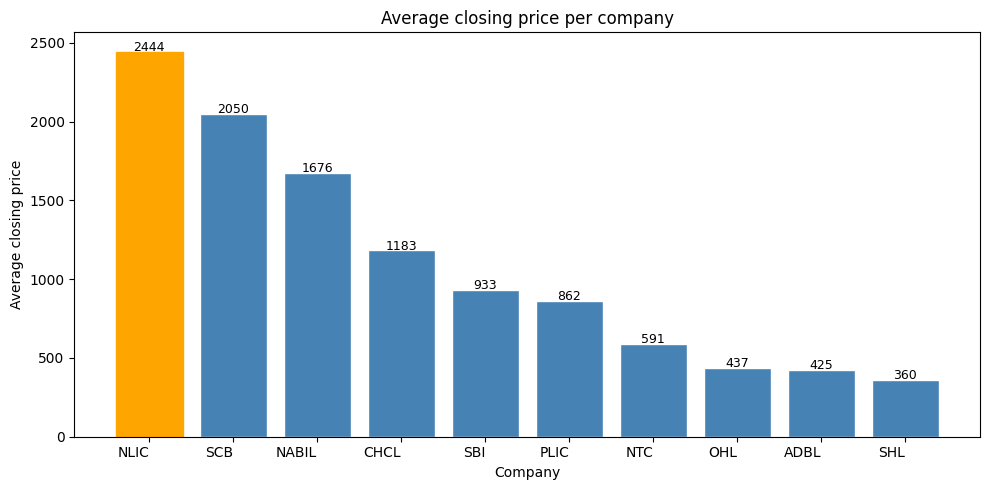

In [59]:
#Q38. Plot a bar chart showing the average closing price for each company. Which company stands out?

avg_price = df.groupby("symbol")["closingprice"].mean().round(2)
avg_price = avg_price.sort_values(ascending = False)

plt.figure(figsize=(10,5))
bars = plt.bar(avg_price.index, avg_price.values, color ="steelblue",edgecolor="white")
bars[0].set_color("orange")
for bar in bars:
    plt.text(
        bar.get_x()+ bar.get_width()/2,
        bar.get_height()+5,
        f"{bar.get_height():.0f}",
        ha = "center", fontsize = 9
    )
plt.title("Average closing price per company")
plt.xlabel("Company")
plt.ylabel("Average closing price")
plt.xticks(rotation = 360, ha = "right")

plt.tight_layout()
plt.show()

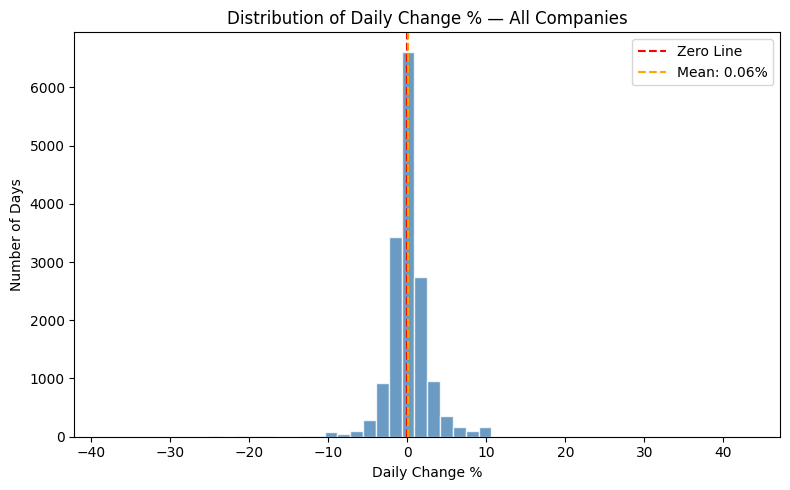

In [60]:
#Q39. Plot a histogram of daily_change_pct for all companies combined. Where do most days cluster?

data = df["daily_change_pct"].replace([np.inf,-np.inf],np.nan).dropna()
plt.figure(figsize=(8, 5))
plt.hist(data,
         bins=50,
         color="steelblue",
         edgecolor="white",
         alpha=0.8)
plt.axvline(x=0,
            color="red",
            linestyle="--",
            linewidth=1.5,
            label="Zero Line")
plt.axvline(x=data.mean(),
            color="orange",
            linestyle="--",
            linewidth=1.5,
            label=f"Mean: {data.mean():.2f}%")
plt.title("Distribution of Daily Change % — All Companies")
plt.xlabel("Daily Change %")
plt.ylabel("Number of Days")
plt.legend()

plt.tight_layout()
plt.show()

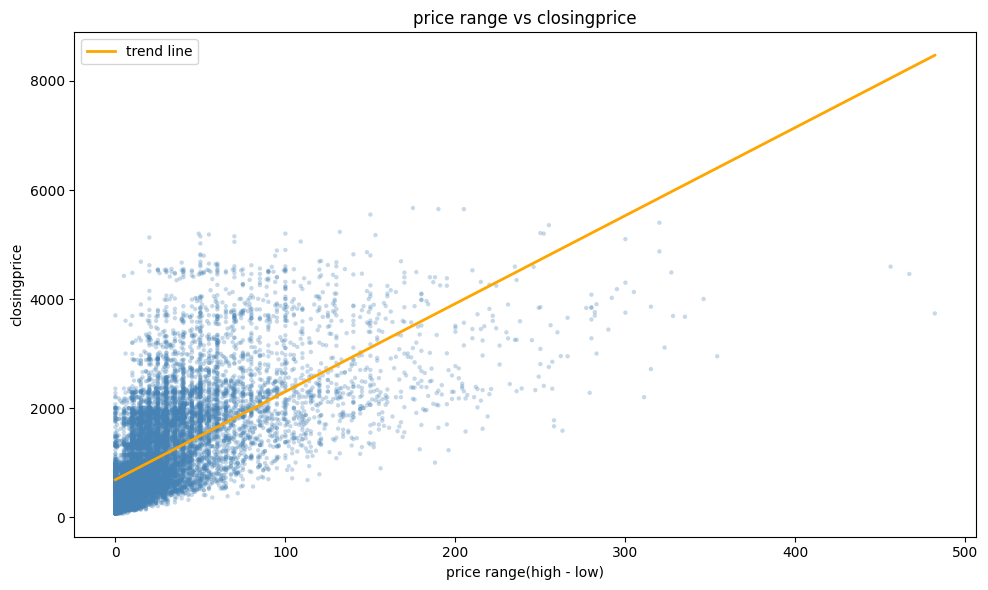

In [62]:
#Q40. Plot a scatter chart of price_range (X-axis) vs closingprice(Y-axis). Does higher price mean more volatility?

df["price_range"] = df["maxprice"] - df["minprice"]
scatter_data = df[["price_range","closingprice"]].dropna()

plt.figure(figsize=(10,6))
plt.scatter(scatter_data["price_range"],
            scatter_data["closingprice"],
            alpha = 0.3,
            color = "steelblue",
            edgecolors = "none",
            s = 10)

z = np.polyfit(scatter_data["price_range"],
               scatter_data["closingprice"],1)
p = np.poly1d(z)
plt.plot(sorted(scatter_data["price_range"]),
         p(sorted(scatter_data["price_range"])),
         color = "orange",
         linewidth = 2,
         label = "trend line")
plt.title("price range vs closingprice")
plt.xlabel("price range(high - low)")
plt.ylabel("closingprice")
plt.legend()

plt.tight_layout()
plt.show()

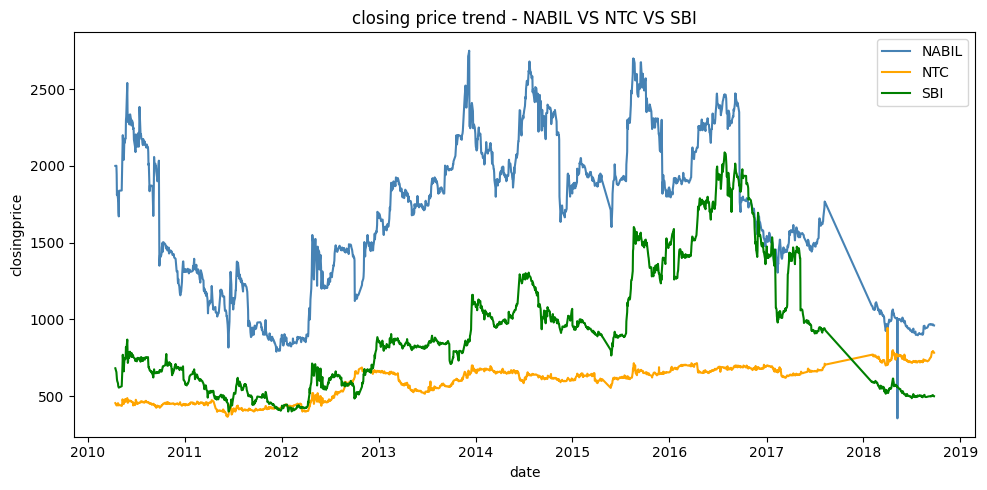

In [65]:
#Q41. Plot a line chart comparing the closing price trend of NABIL, NTC, and SBI on the same chart with different colours and a legend.
nabil = df[df["symbol"] == "NABIL"].sort_values("date")
ntc = df[df["symbol"] == "NTC"].sort_values("date")
sbi = df[df["symbol"] == "SBI"].sort_values("date")

plt.figure(figsize=(10,5))
plt.plot(nabil["date"],nabil["closingprice"],
         color = "steelblue",
         linewidth = 1.5,
         label = "NABIL")
plt.plot(ntc["date"],ntc["closingprice"],
         color = "orange",
         linewidth = 1.5,
         label = "NTC")
plt.plot(sbi["date"],sbi["closingprice"],
         color = "green",
         linewidth = 1.5,
         label = "SBI")
plt.title("closing price trend - NABIL VS NTC VS SBI")
plt.xlabel("date")
plt.ylabel("closingprice")
plt.legend()

plt.tight_layout()
plt.show()

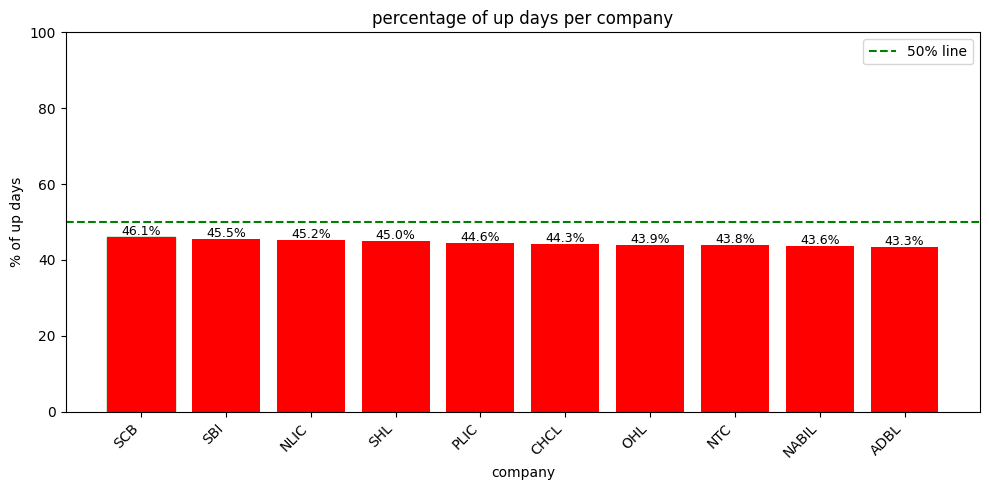

In [120]:
#Q42. Plot a bar chart showing the percentage of 'Up' days for each company. Which company is most consistently positive?

up_pct = (
    df[df["day_result"] == "Up"]
    .groupby("symbol")["day_result"]
    .count()/
    df.groupby("symbol")["day_result"]
    .count()* 100
).round(2)

up_pct = up_pct.sort_values(ascending = False)

plt.figure(figsize=(10,5))
bars = plt.bar(up_pct.index,
               up_pct.values,
               color = "steelblue",
               edgecolor = "white")
bars[0].set_color("green")
plt.axhline(y = 50,
            color = "green",
            linewidth = 1.5,
            linestyle = "--",
            label ="50% line")
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+0.5,
        f"{bar.get_height():.1f}%",
        ha = "center",
        fontsize = 9
    )
plt.title ("percentage of up days per company")
plt.xlabel("company")
plt.ylabel("% of up days")
plt.ylim(0,100)
plt.legend()
plt.xticks(rotation = 45, ha = "right")

colors = ["green" if v > 50 else "red" for v in up_pct.values]
plt.bar(up_pct.index, up_pct.values, color=colors)

plt.tight_layout()
plt.show()

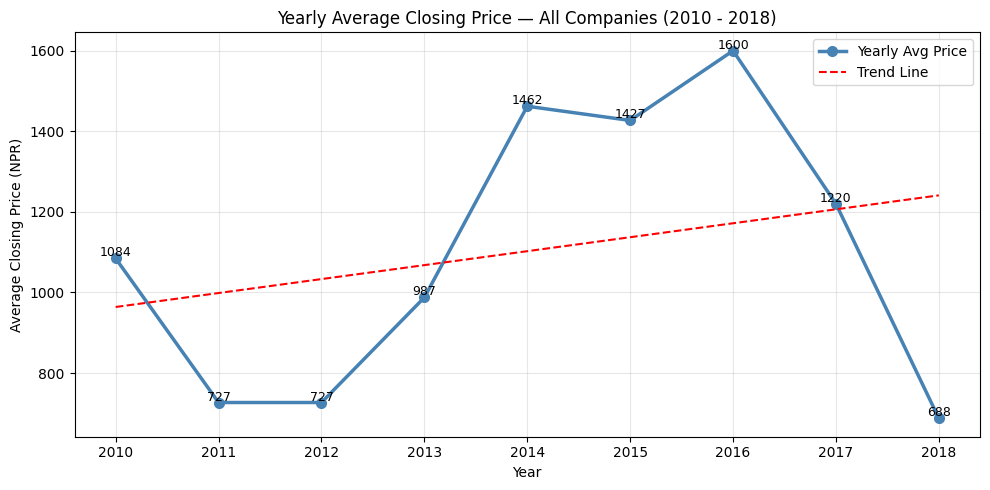

In [83]:
#Q43. Plot a line chart showing the yearly average closing price (all companies combined) from 2010 to 2018.Was the overall trend going up or down?

yearly_avg = df.groupby("year")["closingprice"].mean().round(2)
yearly_avg = yearly_avg.loc[2010:2018]

plt.figure(figsize=(10, 5))
plt.plot(yearly_avg.index, yearly_avg.values,
         color="steelblue",
         linewidth=2.5,
         marker="o",
         markersize=7,
         label="Yearly Avg Price")
import numpy as np
z = np.polyfit(yearly_avg.index, yearly_avg.values, 1)
p = np.poly1d(z)
plt.plot(yearly_avg.index,
         p(yearly_avg.index),
         color="red",
         linewidth=1.5,
         linestyle="--",
         label="Trend Line")
for x, y in zip(yearly_avg.index, yearly_avg.values):
    plt.text(x, y + 5,           
             f"{y:.0f}",
             ha="center",
             fontsize=9)
plt.title("Yearly Average Closing Price — All Companies (2010 - 2018)")
plt.xlabel("Year")
plt.ylabel("Average Closing Price (NPR)")
plt.xticks(yearly_avg.index)      
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Skewness  : 0.38


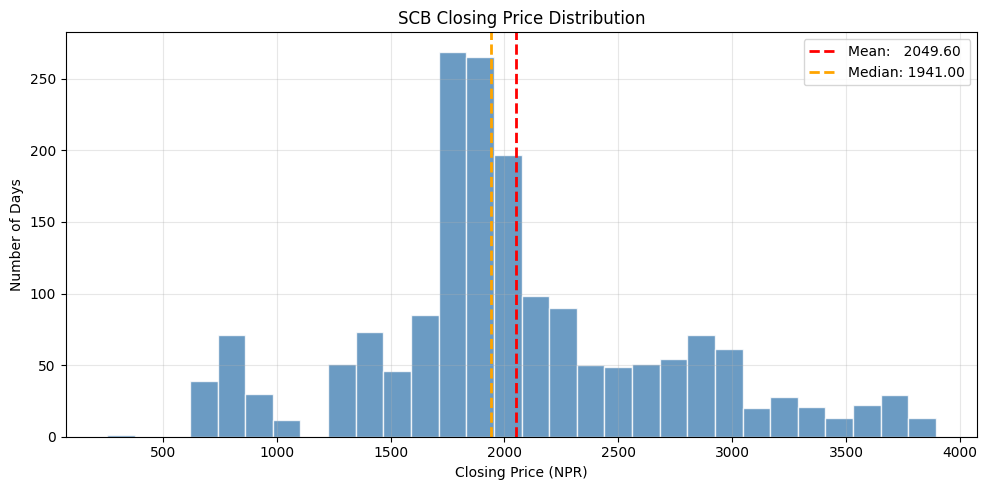

In [ ]:
#Q44. Plot a histogram showing the distribution of closing prices for SCB only. Is it normally distributed or skewed?

scb = df[df["symbol"] == "SCB"]["closingprice"].dropna()

plt.figure(figsize=(10, 5))
plt.hist(scb,
         bins=30,
         color="steelblue",
         edgecolor="white",
         alpha=0.8)
plt.axvline(x=scb.mean(),
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"Mean:   {scb.mean():.2f}")
plt.axvline(x=scb.median(),
            color="orange",
            linestyle="--",
            linewidth=2,
            label=f"Median: {scb.median():.2f}")
plt.title("SCB Closing Price Distribution")
plt.xlabel("Closing Price (NPR)")
plt.ylabel("Number of Days")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [93]:
mean   = scb.mean()
median = scb.median()

if abs(mean - median) < 10:
    print("Fairly Normal Distribution")
elif mean > median:
    print("Right Skewed → few very HIGH prices pulling mean up")
else:
    print("Left Skewed  → few very LOW prices pulling mean down")

Right Skewed → few very HIGH prices pulling mean up


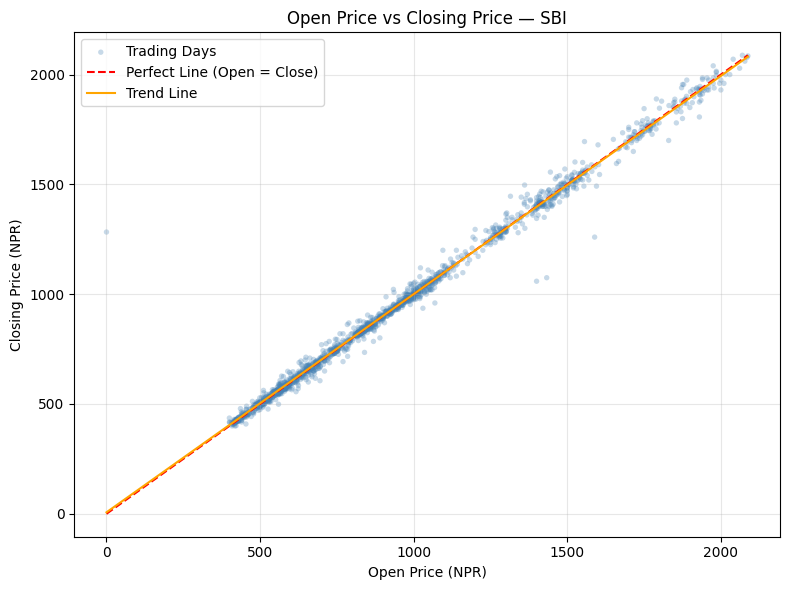

In [98]:
#Q45. Plot a scatter chart of openprice (X-axis) vs closingprice(Y-axis) for SBI. Do they follow each other closely?

sbi = df[df["symbol"] == "SBI"][["openprice", "closingprice"]].dropna()

plt.figure(figsize=(8, 6))
plt.scatter(sbi["openprice"],
            sbi["closingprice"],
            alpha=0.3,
            color="steelblue",
            edgecolors="none",
            s=15,
            label="Trading Days")
min_val = min(sbi["openprice"].min(), sbi["closingprice"].min())
max_val = max(sbi["openprice"].max(), sbi["closingprice"].max())
plt.plot([min_val, max_val],
         [min_val, max_val],
         color="red",
         linewidth=1.5,
         linestyle="--",
         label="Perfect Line (Open = Close)")
z = np.polyfit(sbi["openprice"], sbi["closingprice"], 1)
p = np.poly1d(z)
plt.plot(sorted(sbi["openprice"]),
         p(sorted(sbi["openprice"])),
         color="orange",
         linewidth=1.5,
         label="Trend Line")
plt.title("Open Price vs Closing Price — SBI")
plt.xlabel("Open Price (NPR)")
plt.ylabel("Closing Price (NPR)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

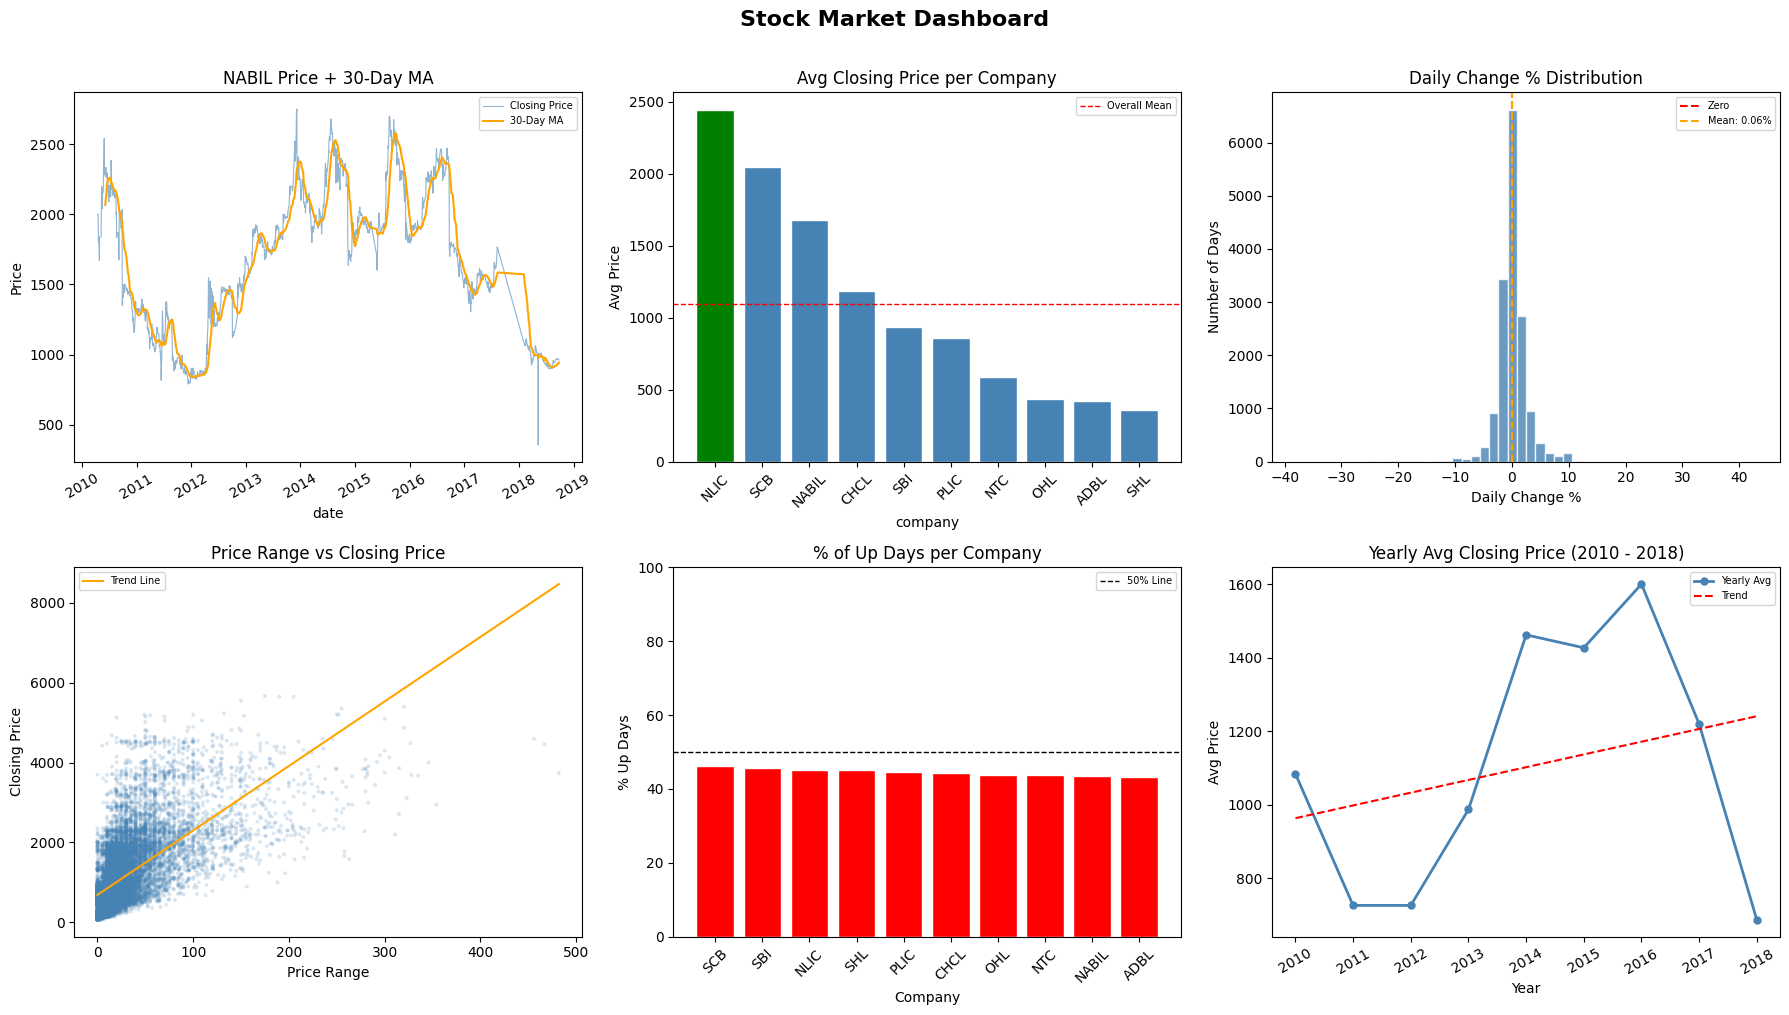

In [ ]:
#Q46
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Stock Market Dashboard", fontsize=16, fontweight="bold", y=1.01)

#Box 1 -> NABIL closing price trend + 30-day moving average (line)
nabil = df[df["symbol"] == "NABIL"].sort_values("date")
nabil["MA30"] = nabil["closingprice"].rolling(window=30).mean()

axes[0, 0].plot(nabil["date"], nabil["closingprice"],
                color="steelblue", linewidth=0.8,
                alpha=0.6, label="Closing Price")
axes[0, 0].plot(nabil["date"], nabil["MA30"],
                color="orange", linewidth=1.5,
                label="30-Day MA")
axes[0, 0].set_title("NABIL Price + 30-Day MA")
axes[0, 0].set_xlabel("date")
axes[0, 0].set_ylabel("Price")
axes[0, 0].legend(fontsize=7)
axes[0, 0].tick_params(axis="x", rotation=30)

# Box 2 — Average Closing Price per Company
avg_price = df.groupby("symbol")["closingprice"].mean().round(2)
avg_price = avg_price.sort_values(ascending=False)
colors    = ["green"] + ["steelblue"] * (len(avg_price) - 1)

axes[0, 1].bar(avg_price.index, avg_price.values,
               color=colors, edgecolor="white")
axes[0, 1].axhline(y=avg_price.mean(),
                   color="red", linestyle="--",
                   linewidth=1, label="Overall Mean")
axes[0, 1].set_title("Avg Closing Price per Company")
axes[0, 1].set_xlabel("company")
axes[0, 1].set_ylabel("Avg Price")
axes[0, 1].legend(fontsize=7)
axes[0, 1].tick_params(axis="x", rotation=45)

# Box 3 — Daily Change % Distribution
changes = df["daily_change_pct"].replace([np.inf, -np.inf], np.nan).dropna()

axes[0, 2].hist(changes, bins=50,
                color="steelblue",
                edgecolor="white",
                alpha=0.8)
axes[0, 2].axvline(x=0,
                   color="red", linestyle="--",
                   linewidth=1.5, label="Zero")
axes[0, 2].axvline(x=changes.mean(),
                   color="orange", linestyle="--",
                   linewidth=1.5,
                   label=f"Mean: {changes.mean():.2f}%")
axes[0, 2].set_title("Daily Change % Distribution")
axes[0, 2].set_xlabel("Daily Change %")
axes[0, 2].set_ylabel("Number of Days")
axes[0, 2].legend(fontsize=7)

# Box 4 — Price Range vs Closing Price
scatter = df[["price_range", "closingprice"]].dropna()

axes[1, 0].scatter(scatter["price_range"],
                   scatter["closingprice"],
                   alpha=0.2, color="steelblue",
                   edgecolors="none", s=8)
z = np.polyfit(scatter["price_range"], scatter["closingprice"], 1)
p = np.poly1d(z)
axes[1, 0].plot(sorted(scatter["price_range"]),
                p(sorted(scatter["price_range"])),
                color="orange", linewidth=1.5,
                label="Trend Line")
axes[1, 0].set_title("Price Range vs Closing Price")
axes[1, 0].set_xlabel("Price Range")
axes[1, 0].set_ylabel("Closing Price")
axes[1, 0].legend(fontsize=7)

# Box 5 — % of Up Days per Company
up_pct = df.groupby("symbol").apply(
    lambda x: (x["day_result"] == "Up").sum() / len(x) * 100
).round(2).sort_values(ascending=False)

bar_colors = ["green" if v > 50 else "red" for v in up_pct.values]
axes[1, 1].bar(up_pct.index, up_pct.values,
               color=bar_colors, edgecolor="white")
axes[1, 1].axhline(y=50,
                   color="black", linestyle="--",
                   linewidth=1, label="50% Line")
axes[1, 1].set_title("% of Up Days per Company")
axes[1, 1].set_xlabel("Company")
axes[1, 1].set_ylabel("% Up Days")
axes[1, 1].set_ylim(0, 100)
axes[1, 1].legend(fontsize=7)
axes[1, 1].tick_params(axis="x", rotation=45)

# Box 6 — Yearly Average Closing Price
yearly_avg = df.groupby("year")["closingprice"].mean().round(2)
yearly_avg = yearly_avg.loc[2010:2018]

axes[1, 2].plot(yearly_avg.index, yearly_avg.values,
                color="steelblue", linewidth=2,
                marker="o", markersize=5,
                label="Yearly Avg")
z2 = np.polyfit(yearly_avg.index, yearly_avg.values, 1)
p2 = np.poly1d(z2)
axes[1, 2].plot(yearly_avg.index, p2(yearly_avg.index),
                color="red", linewidth=1.5,
                linestyle="--", label="Trend")
axes[1, 2].set_title("Yearly Avg Closing Price (2010 - 2018)")
axes[1, 2].set_xlabel("Year")
axes[1, 2].set_ylabel("Avg Price")
axes[1, 2].legend(fontsize=7)
axes[1, 2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [102]:
#Q47. Save the dashboard from Q46 as nepse_dashboard.png with dpi=300 and bbox_inches='tight'.

plt.savefig("nepse_dashboard.png",
            dpi=300,
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

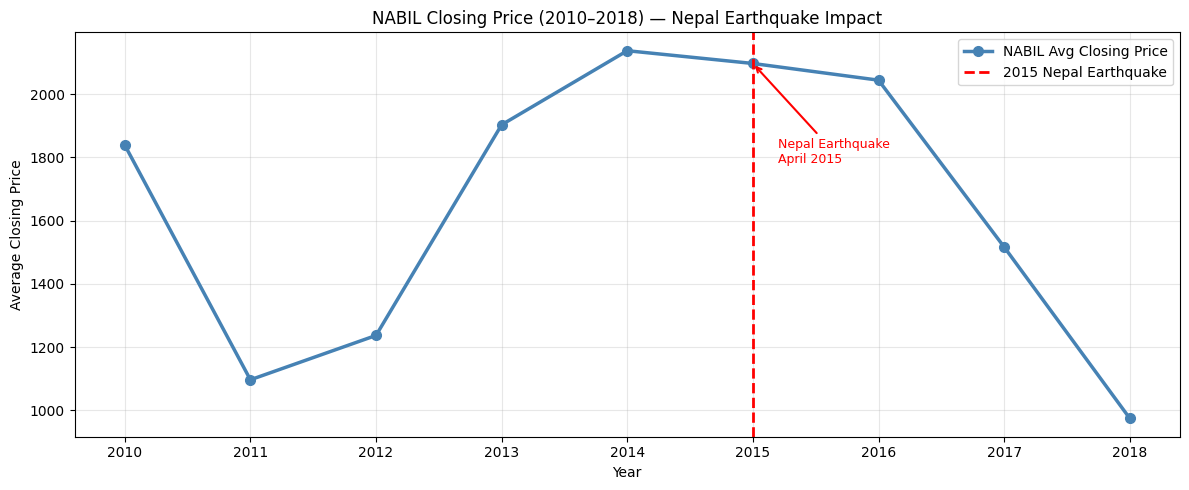

In [103]:
#Q48. Add a red dashed vertical line on the NABIL line chart (Q36)marking the year 2015 — when the Nepal earthquake happened.Does the chart show any impact?

nabil = df[df["symbol"] == "NABIL"].sort_values("date")
nabil_yearly = nabil.groupby("year")["closingprice"].mean()
nabil_yearly = nabil_yearly.loc[2010:2018]

plt.figure(figsize=(12, 5))
plt.plot(nabil_yearly.index, nabil_yearly.values,
         color="steelblue",
         linewidth=2.5,
         marker="o",
         markersize=7,
         label="NABIL Avg Closing Price")
plt.axvline(x=2015,
            color="red",
            linestyle="--",
            linewidth=2,
            label="2015 Nepal Earthquake")
plt.annotate("Nepal Earthquake\nApril 2015",
             xy=(2015, nabil_yearly.loc[2015]),      
             xytext=(2015.2, nabil_yearly.loc[2015] * 0.85), 
             fontsize=9,
             color="red",
             arrowprops=dict(
                 arrowstyle="->",
                 color="red",
                 lw=1.5
             ))
plt.title("NABIL Closing Price (2010–2018) — Nepal Earthquake Impact")
plt.xlabel("Year")
plt.ylabel("Average Closing Price")
plt.xticks(nabil_yearly.index)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

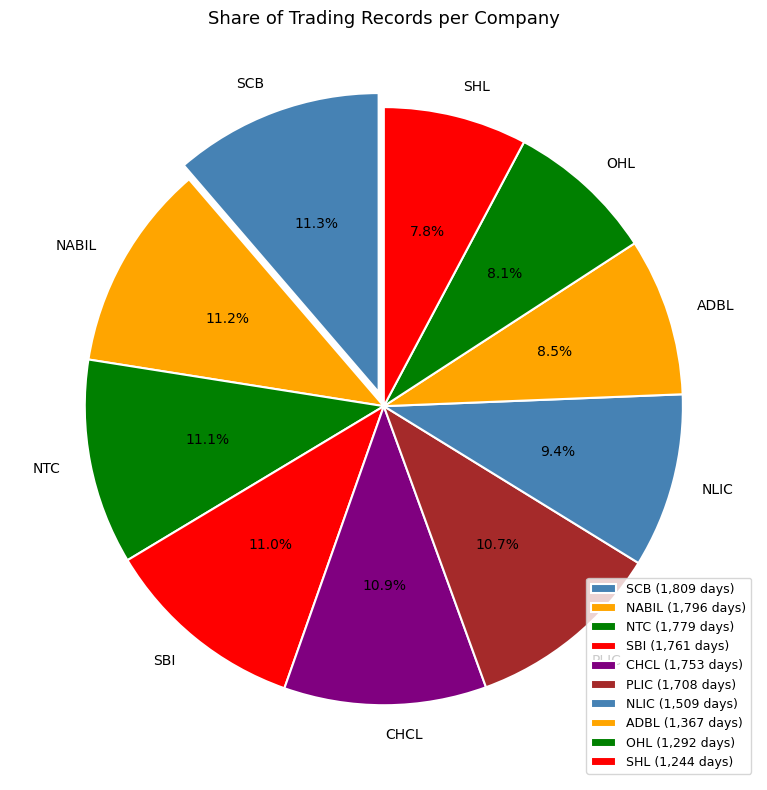

In [109]:
#Q49. Plot a pie chart showing what share of total trading records each company holds in the dataset.

company_counts = df["symbol"].value_counts()
explode = [0.05 if i == 0 else 0
           for i in range(len(company_counts))]
plt.figure(figsize=(8, 8))
plt.pie(company_counts.values,
        labels=company_counts.index,
        autopct="%1.1f%%",
        startangle=90,
        explode=explode,
        colors=["steelblue", "orange", "green",
                "red", "purple", "brown"],
        wedgeprops={"edgecolor": "white",
                    "linewidth": 1.5})
legend_labels = [f"{company} ({count:,} days)"
                 for company, count in company_counts.items()]
plt.legend(legend_labels,
           loc="lower right",
           fontsize=9)

plt.title("Share of Trading Records per Company", fontsize=13)
plt.tight_layout()
plt.show()

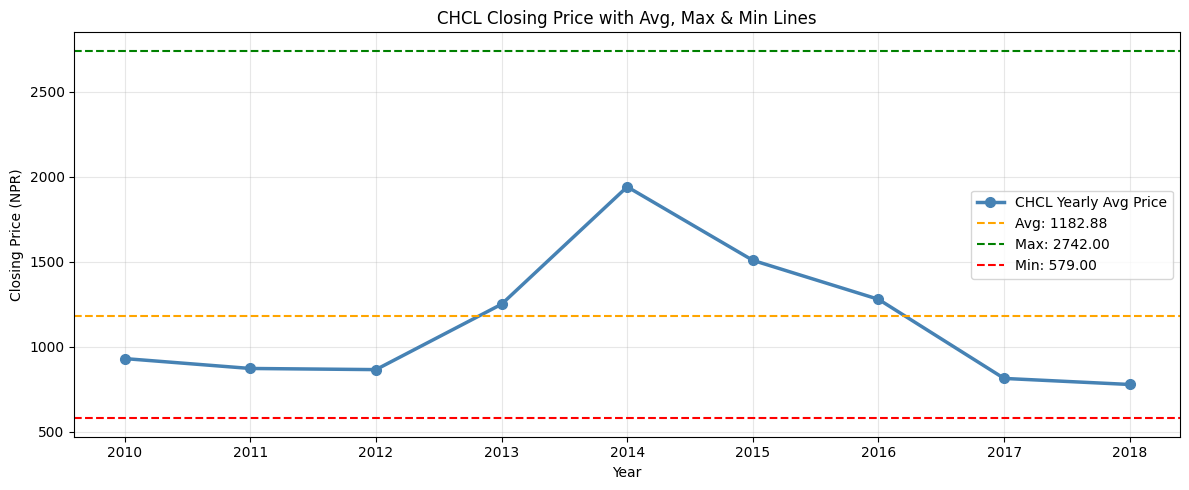

In [110]:
#Q50. Plot a line chart for CHCL closing price. Add horizontal lines marking the average, maximum, and minimum prices using plt.axhline().

chcl = df[df["symbol"] == "CHCL"].sort_values("date")
chcl_yearly = chcl.groupby("year")["closingprice"].mean().round(2)

avg_price = chcl["closingprice"].mean()
max_price = chcl["closingprice"].max()
min_price = chcl["closingprice"].min()

plt.figure(figsize=(12, 5))
plt.plot(chcl_yearly.index, chcl_yearly.values,
         color="steelblue",
         linewidth=2.5,
         marker="o",
         markersize=7,
         label="CHCL Yearly Avg Price")

plt.axhline(y=avg_price,
            color="orange",
            linestyle="--",
            linewidth=1.5,
            label=f"Avg: {avg_price:.2f}")

plt.axhline(y=max_price,
            color="green",
            linestyle="--",
            linewidth=1.5,
            label=f"Max: {max_price:.2f}")

plt.axhline(y=min_price,
            color="red",
            linestyle="--",
            linewidth=1.5,
            label=f"Min: {min_price:.2f}")

plt.title("CHCL Closing Price with Avg, Max & Min Lines")
plt.xlabel("Year")
plt.ylabel("Closing Price (NPR)")
plt.xticks(chcl_yearly.index)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()